In [ ]:
import torch
from diffusers import StableDiffusion3Pipeline
from huggingface_hub import login
# Import the userdata module from colab
from google.colab import userdata

# Safely pull the secret from Colab
login(token=hf_token)

DEVICE = "cuda"
DTYPE = torch.float16

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    torch_dtype=DTYPE,
).to(DEVICE)


model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [63]:
# ── CONFIG ─────────────────────────────────────────────────────────────
CONCEPT_PROMPT  = "a bed"             # what to steer away from
NEUTRAL_PROMPT  = "a room"            # neutral baseline
GEN_PROMPT      = "a room with a bed" # prompt used at generation time
ALPHA_PAIRS     = [(0,0), (0,4), (0,8), (0,10), (5,2), (5,4), (5,8), (5,10)]
NUM_STEPS       = 10
GUIDANCE_SCALE  = 7.0
SEED            = 42
# ────────────────────────────────────────────────────────────────────────

In [61]:
def clear_all_hooks():
    pipe.transformer.time_text_embed._forward_hooks.clear()
    pipe.transformer.time_text_embed._forward_pre_hooks.clear()
    pipe.transformer.context_embedder._forward_hooks.clear()
    pipe.transformer.context_embedder._forward_pre_hooks.clear()
    for blk in pipe.transformer.transformer_blocks:
        blk._forward_hooks.clear()
        blk._forward_pre_hooks.clear()
clear_all_hooks()

def masked_mean(act, prompt, tokenizer, max_length):
    tok  = tokenizer(prompt, return_tensors="pt", padding="max_length",
                     max_length=max_length, truncation=True)
    mask = tok.attention_mask[0].bool()
    return act[mask].mean(dim=0)

def capture_per_step(prompt):
    steps = {}
    counter = [0]
    def _hook(module, inp, out):
        steps[counter[0]] = out[1].detach().float()  # conditional (333, 1536)
        counter[0] += 1
    h = pipe.transformer.context_embedder.register_forward_hook(_hook)
    with torch.no_grad():
        pipe(prompt, num_inference_steps=NUM_STEPS, output_type="latent",
             generator=torch.Generator(DEVICE).manual_seed(0))
    h.remove()
    return steps

print("Capturing concept activations...")
concept_steps = capture_per_step(CONCEPT_PROMPT)
print("Capturing neutral activations...")
neutral_steps = capture_per_step(NEUTRAL_PROMPT)

# Compute per-step directions for CLIP-L and T5 ranges
dir_clip_steps = {}
dir_t5_steps   = {}

for step in range(NUM_STEPS):
    diff = concept_steps[step] - neutral_steps[step]  # (333, 1536)

    d_clip = masked_mean(diff[:77],  CONCEPT_PROMPT, pipe.tokenizer,  77)
    d_clip = d_clip / (d_clip.norm() + 1e-8)
    dir_clip_steps[step] = d_clip.to(DEVICE, dtype=DTYPE)

    if pipe.tokenizer_3 is not None:
        d_t5 = masked_mean(diff[77:], CONCEPT_PROMPT, pipe.tokenizer_3, 256)
        d_t5 = d_t5 / (d_t5.norm() + 1e-8)
        dir_t5_steps[step] = d_t5.to(DEVICE, dtype=DTYPE)

print(f"Captured {len(dir_clip_steps)} per-step directions for CLIP-L")
print(f"Captured {len(dir_t5_steps)} per-step directions for T5")

Capturing concept activations...


  0%|          | 0/10 [00:00<?, ?it/s]

Capturing neutral activations...


  0%|          | 0/10 [00:00<?, ?it/s]

Captured 10 per-step directions for CLIP-L
Captured 10 per-step directions for T5


In [14]:
clear_all_hooks()

with torch.no_grad():
    baseline = pipe(
        GEN_PROMPT,
        guidance_scale=GUIDANCE_SCALE,
        num_inference_steps=NUM_STEPS,
        generator=torch.Generator(DEVICE).manual_seed(SEED),
    ).images[0]

clear_all_hooks()
# display(baseline)
# baseline.save("baseline.png")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

clip=0 t5=0: ok (mean=171.6)


  0%|          | 0/10 [00:00<?, ?it/s]

clip=0 t5=4: ok (mean=170.5)


  0%|          | 0/10 [00:00<?, ?it/s]

...

clip=5 t5=4: ok (mean=171.6)


  0%|          | 0/10 [00:00<?, ?it/s]

clip=5 t5=8: ok (mean=169.0)


  0%|          | 0/10 [00:00<?, ?it/s]

clip=5 t5=10: ok (mean=169.2)


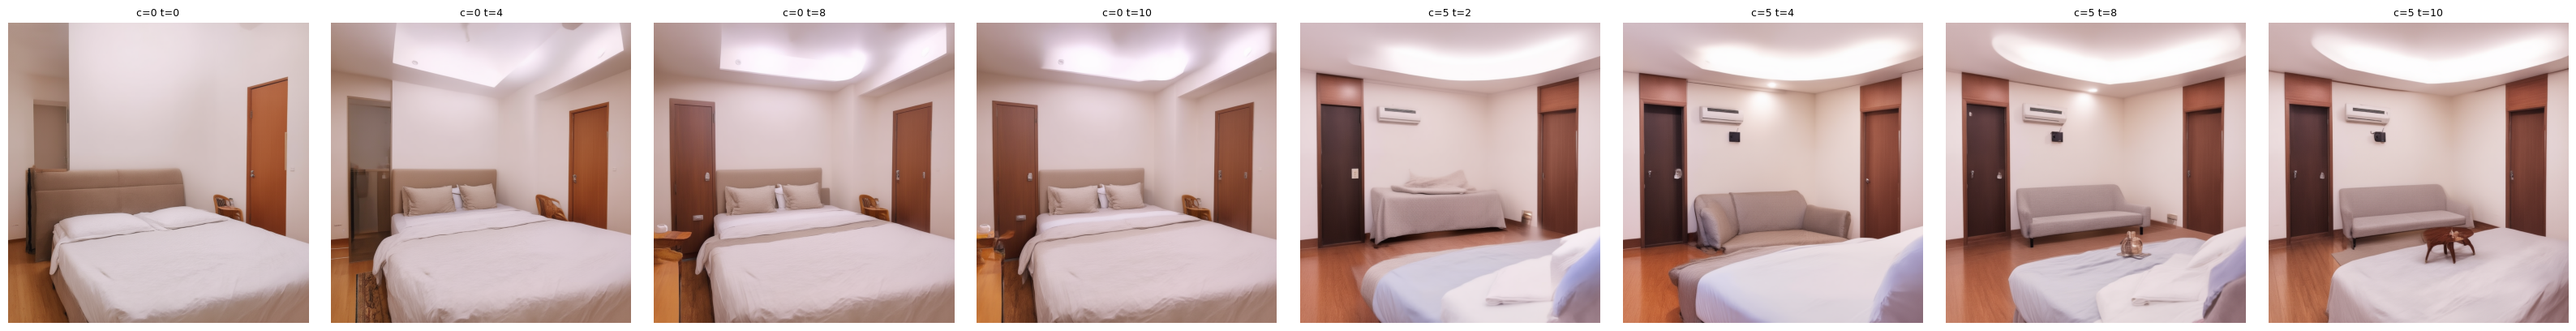

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

def make_placeholder(label):
    img = Image.new('RGB', (512, 512), (40, 40, 40))
    ImageDraw.Draw(img).text((180, 240), f"{label}\nNaN/OOB", fill=(255, 80, 80))
    return img

images = []
for a_clip, a_t5 in ALPHA_PAIRS:
    counter = [0]

    def _hook(module, inp, out, _ac=a_clip, _at=a_t5):
        step = counter[0] % NUM_STEPS
        counter[0] += 1
        out_f = out.clone().float()

        # CLIP-L tokens
        d = dir_clip_steps[step].float()
        proj = torch.clamp(out_f[:, :77, :] @ d, min=0.0).unsqueeze(-1)
        out_f[:, :77, :] -= _ac * proj * d

        # T5 tokens
        if step in dir_t5_steps:
            d = dir_t5_steps[step].float()
            proj = torch.clamp(out_f[:, 77:, :] @ d, min=0.0).unsqueeze(-1)
            out_f[:, 77:, :] -= _at * proj * d

        return out_f.to(out.dtype)

    h = pipe.transformer.context_embedder.register_forward_hook(_hook)
    try:
        with torch.no_grad():
            img = pipe(
                GEN_PROMPT,
                guidance_scale=GUIDANCE_SCALE,
                num_inference_steps=NUM_STEPS,
                generator=torch.Generator(DEVICE).manual_seed(SEED),
            ).images[0]
        arr = np.array(img)
        if arr.mean() > 250 or arr.mean() < 5:
            print(f"clip={a_clip} t5={a_t5}: degenerate (mean={arr.mean():.1f})")
            img = make_placeholder(f"c={a_clip} t={a_t5}")
        else:
            print(f"clip={a_clip} t5={a_t5}: ok (mean={arr.mean():.1f})")
    except Exception as e:
        print(f"clip={a_clip} t5={a_t5}: error — {e}")
        img = make_placeholder(f"c={a_clip} t={a_t5}")
    finally:
        h.remove()
    images.append((a_clip, a_t5, img))

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
for ax, (ac, at, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(f"c={ac} t={at}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Running: baseline


  0%|          | 0/10 [00:00<?, ?it/s]

Running: zero pooled


  0%|          | 0/10 [00:00<?, ?it/s]

Running: zero context


  0%|          | 0/10 [00:00<?, ?it/s]

Running: zero CLIP-L seq


  0%|          | 0/10 [00:00<?, ?it/s]

Running: zero T5 seq


  0%|          | 0/10 [00:00<?, ?it/s]

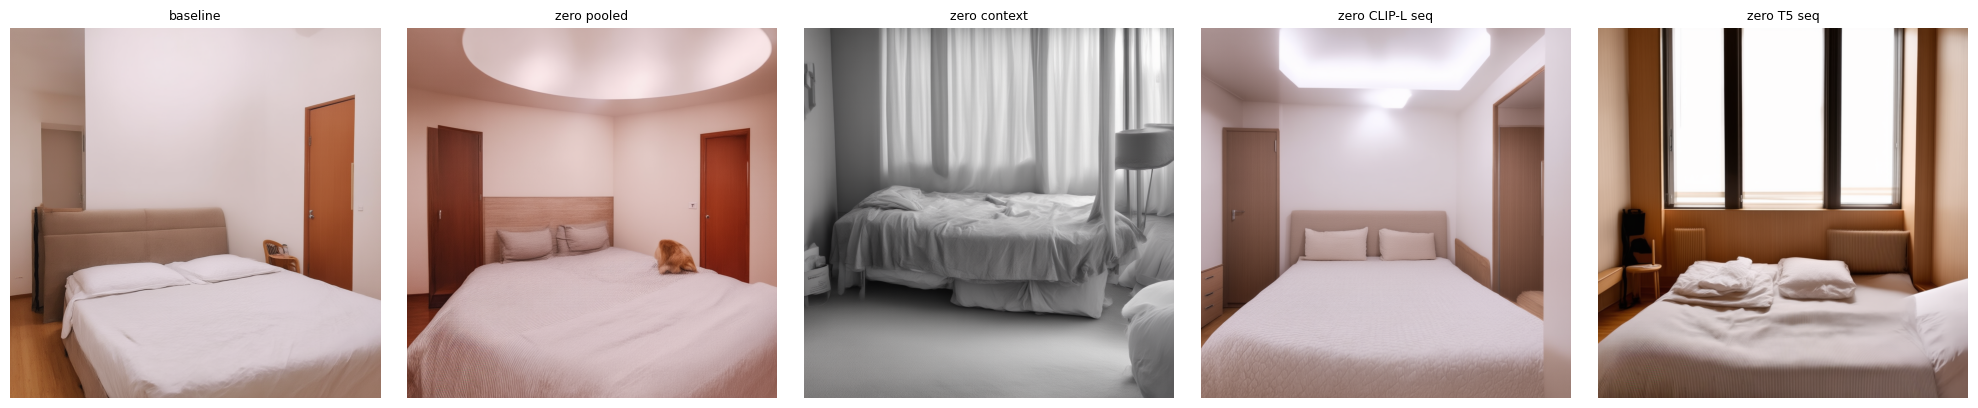

Saved → results/diagnostic.png


In [18]:
import matplotlib.pyplot as plt

def _run(gen_prompt, pre_hook=None, fwd_hook=None):
    handles = []
    if pre_hook:
        handles.append(pipe.transformer.time_text_embed.register_forward_pre_hook(pre_hook))
    if fwd_hook:
        handles.append(pipe.transformer.context_embedder.register_forward_hook(fwd_hook))
    with torch.no_grad():
        img = pipe(
            gen_prompt,
            guidance_scale=GUIDANCE_SCALE,
            num_inference_steps=NUM_STEPS,
            generator=torch.Generator(DEVICE).manual_seed(SEED),
        ).images[0]
    for h in handles: h.remove()
    return img

# Hook definitions
def zero_pooled(module, args):
    timestep, pooled = args
    return (timestep, torch.zeros_like(pooled))

def zero_context(module, inp, out):
    return torch.zeros_like(out)

def zero_clip_seq(module, inp, out):   # positions 0-76 (CLIP-L tokens)
    out = out.clone()
    out[:, :77, :] = 0
    return out

def zero_t5_seq(module, inp, out):    # positions 77-332 (T5 tokens)
    out = out.clone()
    out[:, 77:, :] = 0
    return out

tests = [
    ("baseline",      None,         None),
    ("zero pooled",   zero_pooled,  None),
    ("zero context",  None,         zero_context),
    ("zero CLIP-L seq", None,       zero_clip_seq),
    ("zero T5 seq",   None,         zero_t5_seq),
]

results = []
for label, pre, fwd in tests:
    print(f"Running: {label}")
    results.append((label, _run(GEN_PROMPT, pre, fwd)))

fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
for ax, (label, img) in zip(axes, results):
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
# plt.savefig("results/diagnostic.png", dpi=150)
plt.show()
print("Saved → results/diagnostic.png")